# TP2 : Filtrage Collaboratif

Le filtrage collaboratif est une famille de modèles centraux pour les systèmes de recommandation, que ce soit orienté utilisateurs (*user-based*) ou orienté articles (*item-based*).

On utilise ici le jeu de données **MovieLens 100k** (`ml-100k`) : 100 000 notes explicites (1 à 5) données par environ 1000 utilisateurs sur un peu plus de 1600 films.

## Le jeu de données MovieLens100k

Le jeu de données a été téléchargé depuis [MovieLens](http://files.grouplens.org/datasets/movielens/ml-100k.zip) et décompressé dans le dossier `ml-100k/`. On regarde le contenu du dossier.

In [1]:
import os
os.chdir('ml-100k')
os.listdir()

['u.item',
 'u3.test',
 'u1.base',
 'u.info',
 'u2.test',
 'u5.test',
 'u.genre',
 'ub.test',
 'ua.base',
 'u.data',
 'README',
 'u4.test',
 'u5.base',
 'ub.base',
 'ua.test',
 'u4.base',
 'u.user',
 'allbut.pl',
 'u3.base',
 'u1.test',
 'mku.sh',
 'u2.base',
 'u.occupation']

On s'intéresse surtout au fichier `u.data`, qui contient l'entièreté des 100 000 évaluations. Les données comportent 4 colonnes : `userid`, `itemid`, `rating`, `timestamp`.

In [2]:
!head u.data
!echo
!wc -l u.data

196	242	3	881250949
186	302	3	891717742
22	377	1	878887116
244	51	2	880606923
166	346	1	886397596
298	474	4	884182806
115	265	2	881171488
253	465	5	891628467
305	451	3	886324817
6	86	3	883603013


  100000 u.data


Chargeons cela dans un DataFrame pandas.

In [3]:
import numpy as np
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
import pandas as pd

In [4]:
names = ['user_id', 'item_id', 'rating', 'timestamp']
df = pd.read_csv('u.data', sep='\t', names=names)
df.head()

,user_id,item_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


Vérifions que l'on a bien les statistiques annoncées (environ 1000 utilisateurs, un peu plus de 1600 films).

In [5]:
n_users = df.user_id.unique().shape[0]
n_items = df.item_id.unique().shape[0]
print(str(n_users) + ' utilisateurs')
print(str(n_items) + ' films')

943 utilisateurs
1682 films


## Construction de la matrice d'interactions

Nous disposons dans les données MovieLens d'évaluations explicites : nous allons donc proposer un filtrage collaboratif reposant sur ces notes. Construisons la matrice `ratings` (array NumPy). Comme les identifiants sont indicés à partir de 1 (et que Python indice à partir de 0), un simple décalage de -1 suffit.

In [6]:
ratings = np.zeros((n_users, n_items))
for row in df.itertuples():
    ratings[row.user_id - 1, row.item_id - 1] = row.rating
ratings

array([[5., 3., 4., ..., 0., 0., 0.],
       [4., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [5., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 5., 0., ..., 0., 0., 0.]], shape=(943, 1682))

Calculons à quel point cette matrice est creuse (*sparse*).

In [7]:
sparsity = float(len(ratings.nonzero()[0]))
sparsity /= (ratings.shape[0] * ratings.shape[1])
sparsity *= 100
print('Sparsity: {:4.2f}%'.format(sparsity))

Sparsity: 6.30%


**Question : Que pensez-vous de ce chiffre ?**

Avec seulement ~6% de la matrice remplie, les données sont extrêmement creuses : la très grande majorité des paires (utilisateur, film) n'a jamais été notée. C'est typique des systèmes de recommandation réels (peu d'utilisateurs notent une faible fraction du catalogue), et c'est précisément ce qui justifie le filtrage collaboratif : on cherche à combler ces cases manquantes en s'appuyant sur les utilisateurs (ou objets) similaires plutôt que sur un modèle par paire indépendant. Attention toutefois : ici, on a identifié "valeurs manquantes" et "valeur 0" (hors échelle de notes), en première approximation — un vrai 0 n'existe pas dans l'échelle 1-5, donc l'ambiguïté ne pose pas de problème.

Créons les jeux de données `train` et `test`, en retirant 10 notes par utilisateur, pour les placer dans le jeu de validation (test).

In [8]:
def train_test_split(ratings):
    test = np.zeros(ratings.shape)
    train = ratings.copy()
    for user in range(ratings.shape[0]):
        test_ratings = np.random.choice(ratings[user, :].nonzero()[0],
                                         size=10,
                                         replace=False)
        train[user, test_ratings] = 0.
        test[user, test_ratings] = ratings[user, test_ratings]

    assert(np.all((train * test) == 0))  # on vérifie que train et test sont disjoints
    return train, test

In [9]:
np.random.seed(0)
train, test = train_test_split(ratings)
train, test

(array([[5., 3., 4., ..., 0., 0., 0.],
        [4., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 5., 0., ..., 0., 0., 0.]], shape=(943, 1682)),
 array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [5., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], shape=(943, 1682)))

## Filtrage collaboratif

### Similarité Cosinus

Le filtrage collaboratif, qu'il soit orienté utilisateur (*user-based*) ou article (*item-based*), se fonde sur des calculs de similarité. Dans le cas *user-based*, on calcule des similarités entre paires d'utilisateurs, en vue d'estimer la proximité de leurs manières de noter.

Une mesure de distance assez commune est la **similarité cosinus**. Si l'on considère qu'un utilisateur est une ligne (ou une colonne) de la matrice d'interactions, c'est-à-dire un vecteur, la similarité avec un autre utilisateur consiste à calculer l'angle formé par leurs deux vecteurs :

$$\text{sim}(u, u') = \cos(\theta) = \frac{\mathbf{r}_u \cdot \mathbf{r}_{u'}}{\|\mathbf{r}_u\| \|\mathbf{r}_{u'}\|} = \sum_i \frac{r_{ui} r_{u'i}}{\sqrt{\sum_i r_{ui}^2} \sqrt{\sum_i r_{u'i}^2}}$$

Les notes étant positives, la similarité cosinus aura une valeur entre 0 (pas de similarité) et 1 (similarité maximale).

On écrit une version lente (avec boucles `for`) et une version rapide (vision matricielle et optimisations NumPy). La version lente est présentée pour mémoire, elle est *très* lente. On propose une version "user" et une version "item".

In [10]:
def slow_user_similarity(ratings, kind='user'):
    if kind == 'user':
        axmax = 0
        axmin = 1
    elif kind == 'item':
        axmax = 1
        axmin = 0
    sim = np.zeros((ratings.shape[axmax], ratings.shape[axmax]))
    for u in range(ratings.shape[axmax]):
        for uprime in range(ratings.shape[axmax]):
            rui_sqrd = 0.
            ruprimei_sqrd = 0.
            for i in range(ratings.shape[axmin]):
                sim[u, uprime] = ratings[u, i] * ratings[uprime, i]
                rui_sqrd += ratings[u, i] ** 2
                ruprimei_sqrd += ratings[uprime, i] ** 2
            sim[u, uprime] /= rui_sqrd * ruprimei_sqrd
    return sim

def fast_similarity(ratings, kind='user', epsilon=1e-9):
    # epsilon -> small number for handling dived-by-zero errors
    if kind == 'user':
        sim = ratings.dot(ratings.T) + epsilon
    elif kind == 'item':
        sim = ratings.T.dot(ratings) + epsilon
    norms = np.array([np.sqrt(np.diagonal(sim))])
    return (sim / norms / norms.T)

In [11]:
#%timeit slow_user_similarity(train)

In [12]:
%timeit fast_similarity(train, kind='user')

15.3 ms ± 502 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [13]:
user_similarity = fast_similarity(train, kind='user')
item_similarity = fast_similarity(train, kind='item')
print(user_similarity[:5, :5])

[[1.         0.14971307 0.03905355 0.05301196 0.36493224]
 [0.14971307 1.         0.11611837 0.15900017 0.07995677]
 [0.03905355 0.11611837 1.         0.21029038 0.02425788]
 [0.05301196 0.15900017 0.21029038 1.         0.02781854]
 [0.36493224 0.07995677 0.02425788 0.02781854 1.        ]]


**Question : cherchez l'utilisateur le plus similaire à l'utilisateur 1 (indicé 0 dans `train`).**

In [14]:
# on exclut l'utilisateur lui-même (similarité de 1 avec lui-même) en le masquant
sims_to_user0 = user_similarity[0].copy()
sims_to_user0[0] = -1
most_similar_user = np.argmax(sims_to_user0)
print(f"Utilisateur le plus similaire à l'utilisateur 1 (indice 0) : indice {most_similar_user} "
      f"(id {most_similar_user + 1}), similarité = {sims_to_user0[most_similar_user]:.4f}")

Utilisateur le plus similaire à l'utilisateur 1 (indice 0) : indice 915 (id 916), similarité = 0.5575


### Premières prédictions de notes

Nous allons maintenant pouvoir proposer de premières prédictions de notes pour les évaluations non présentes dans la matrice initiale. On pourra ensuite comparer ces notes avec les données placées dans `test`, pour évaluer la qualité de notre modèle de recommandation.

On prédit une note d'un utilisateur $u$ pour un item $i$ par la moyenne pondérée des notes des autres utilisateurs, avec les poids égaux aux similarités cosinus entre les autres utilisateurs et $u$, normalisée par la somme des similarités :

$$\hat{r}_{ui} = \frac{\sum_{u'} \text{sim}(u, u') \cdot r_{u'i}}{\sum_{u'} |\text{sim}(u, u')|}$$

À nouveau, on utilise les optimisations NumPy pour accélérer les calculs. Le calcul "rapide" n'est, tout de même, pas instantané.

In [15]:
def predict_slow_simple(ratings, similarity, kind='user'):
    pred = np.zeros(ratings.shape)
    if kind == 'user':
        for i in range(ratings.shape[0]):
            for j in range(ratings.shape[1]):
                pred[i, j] = similarity[i, :].dot(ratings[:, j])\
                             / np.sum(np.abs(similarity[i, :]))
        return pred
    elif kind == 'item':
        for i in range(ratings.shape[0]):
            for j in range(ratings.shape[1]):
                pred[i, j] = similarity[j, :].dot(ratings[i, :].T)\
                             / np.sum(np.abs(similarity[j, :]))
        return pred

def predict_fast_simple(ratings, similarity, kind='user'):
    if kind == 'user':
        return similarity.dot(ratings) / np.array([np.abs(similarity).sum(axis=1)]).T
    elif kind == 'item':
        return ratings.dot(similarity) / np.array([np.abs(similarity).sum(axis=1)])

In [16]:
#%timeit predict_slow_simple(train, user_similarity, kind='user')

In [17]:
%timeit predict_fast_simple(train, user_similarity, kind='user')

22 ms ± 978 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


### Prédictions pour un utilisateur

Conservons la matrice des prédictions.

In [18]:
pred = predict_fast_simple(train, user_similarity, kind='user')

**Question : Calculez les recommandations pour l'utilisateur 1**, en proposant un dictionnaire `recodic` contenant les indices des éléments comme clés, et les notes prédites comme valeurs. On propose aussi un dictionnaire `sortedreco` qui est une version triée par valeurs de `recodic` (indice : `numpy.argpartition`).

In [19]:
user_idx = 0  # utilisateur 1

# recodic : note prédite pour TOUS les films (le but étant de recommander, on ne se limite pas
# aux films déjà notés)
recodic = {item: pred[user_idx, item] for item in range(pred.shape[1])}
sortedreco_all = dict(sorted(recodic.items(), key=lambda kv: kv[1], reverse=True)[:10])
sortedreco_all

{49: np.float64(3.237126649173541),
 173: np.float64(2.7111180314884185),
 180: np.float64(2.686298065921197),
 99: np.float64(2.5728009446572857),
 97: np.float64(2.4694588654094383),
 55: np.float64(2.364663223053548),
 171: np.float64(2.358865975727499),
 126: np.float64(2.336568098490585),
 0: np.float64(2.2713135806744456),
 172: np.float64(2.12355938635201)}

On peut ensuite essayer de comparer aux notes initiales de l'utilisateur. On se donne tout d'abord une fonction simple permettant de retrouver, à partir de l'identifiant d'un utilisateur (tel que défini dans les données, le premier utilisateur a pour identifiant 1) et d'un item, la note associée. On se donne ensuite une fonction permettant d'accéder aux titres de films.

In [20]:
def note_user_item(user, item):
    return ratings[user - 1][item - 1]

In [21]:
colonnes = ['movie id', 'movie title', 'release date', 'video release date', 'IMDb URL',
            'unknown', 'Action', 'Adventure', 'Animation', 'Children', 'Comedy',
            'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'Musical',
            'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']
films = pd.read_csv('u.item', sep='|', names=colonnes, index_col='movie id', encoding='latin-1')
def titre_film(movieid):
    return films.loc[movieid]['movie title']

titre_film(49)

'I.Q. (1994)'

In [22]:
print("Top-10 recommandations (films non notés) pour l'user 0")
unrated_sorted = sorted(
    ((item, score) for item, score in recodic.items() if train[user_idx, item] == 0),
    key=lambda kv: kv[1], reverse=True
)
for item, score in unrated_sorted[:10]:
    print("Élément %.3i, note prédite : %.2f — %s" % (item, score, titre_film(item + 1)))

Top-10 recommandations (films non notés) pour l'user 0
Élément 055, note prédite : 2.36 — Pulp Fiction (1994)
Élément 317, note prédite : 1.94 — Schindler's List (1993)
Élément 182, note prédite : 1.83 — Alien (1979)
Élément 422, note prédite : 1.75 — E.T. the Extra-Terrestrial (1982)
Élément 356, note prédite : 1.68 — One Flew Over the Cuckoo's Nest (1975)
Élément 201, note prédite : 1.68 — Groundhog Day (1993)
Élément 482, note prédite : 1.65 — Casablanca (1942)
Élément 237, note prédite : 1.60 — Raising Arizona (1987)
Élément 287, note prédite : 1.57 — Scream (1996)
Élément 285, note prédite : 1.54 — English Patient, The (1996)


In [23]:
print("Comparaison note prédite / note réelle pour les films déjà notés par l'user 0")
already_rated = train[user_idx, :].nonzero()[0]
sortedreco_rated = dict(sorted({item: pred[user_idx, item] for item in already_rated}.items(),
                                key=lambda kv: kv[1], reverse=True)[:10])
for ind, val in sortedreco_rated.items():
    print("Élément %.3i, note prédite : %.2f" % (ind, val))
    print("--             note réelle :", note_user_item(1, ind + 1))
    print(titre_film(ind + 1))
    print()

Comparaison note prédite / note réelle pour les films déjà notés par l'user 0
Élément 049, note prédite : 3.24
--             note réelle : 5.0
Star Wars (1977)

Élément 173, note prédite : 2.71
--             note réelle : 5.0
Raiders of the Lost Ark (1981)

Élément 180, note prédite : 2.69
--             note réelle : 5.0
Return of the Jedi (1983)

Élément 099, note prédite : 2.57
--             note réelle : 5.0
Fargo (1996)

Élément 097, note prédite : 2.47
--             note réelle : 4.0
Silence of the Lambs, The (1991)

Élément 171, note prédite : 2.36
--             note réelle : 5.0
Empire Strikes Back, The (1980)

Élément 126, note prédite : 2.34
--             note réelle : 5.0
Godfather, The (1972)

Élément 000, note prédite : 2.27
--             note réelle : 5.0
Toy Story (1995)

Élément 172, note prédite : 2.12
--             note réelle : 5.0
Princess Bride, The (1987)

Élément 078, note prédite : 2.11
--             note réelle : 4.0
Fugitive, The (1993)



### Évaluation : (R)MSE

On peut quantifier l'erreur globale sur le jeu de données, une pratique courante qui permet de comparer des algorithmes de recommandation. On peut utiliser la version MSE (*mean squared error*) ou RMSE (*root mean squared error*).

In [24]:
from sklearn.metrics import mean_squared_error

In [25]:
def get_mse(pred, actual):
    # Keep only nonzero terms.
    pred = pred[actual.nonzero()].flatten()
    actual = actual[actual.nonzero()].flatten()
    return mean_squared_error(pred, actual)

In [26]:
item_prediction = predict_fast_simple(train, item_similarity, kind='item')
user_prediction = predict_fast_simple(train, user_similarity, kind='user')

print('User-based CF MSE: ' + str(get_mse(user_prediction, test)))
print('Item-based CF MSE: ' + str(get_mse(item_prediction, test)))

User-based CF MSE: 8.510467252663279
Item-based CF MSE: 11.603179462725853


**Question : Que pensez-vous de ce chiffre ?**

Une MSE autour de 8-9 (soit une RMSE d'environ 3, sur une échelle de notes de 1 à 5) est très élevée — pire qu'une prédiction naïve qui se contenterait de toujours prédire la note moyenne. La raison est que `predict_fast_simple` pondère par *tous* les utilisateurs (ou items), y compris ceux qui sont très peu similaires voire non pertinents, ce qui noie le signal des voisins réellement proches. C'est justement ce que la section suivante (top-$k$) va corriger en restreignant la pondération aux $k$ voisins les plus proches.

### Influence des $k$ plus proches utilisateurs

Nous avons pour le moment utilisé *tous* les utilisateurs pour calculer les notes. Comme indiqué en cours, il est beaucoup plus fréquent de calculer des groupes de pairs (*peer group*), c'est-à-dire des groupes restreints de $k$ utilisateurs très similaires à l'utilisateur pour lequel on veut prédire. L'idée sera ensuite de ne calculer notre somme pondérée qu'avec ces utilisateurs :

$$\hat{r}_{ui} = \frac{\sum_{u'} \text{sim}(u, u') r_{u'i}}{\sum_{u'} |\text{sim}(u, u')|}$$

(le calcul est ici implémenté en version "lente").

In [27]:
def predict_topk(ratings, similarity, kind='user', k=40):
    pred = np.zeros(ratings.shape)
    if kind == 'user':
        for i in range(ratings.shape[0]):
            top_k_users = np.argsort(similarity[:, i])[:-k - 1:-1]
            for j in range(ratings.shape[1]):
                pred[i, j] = similarity[i, :][top_k_users].dot(ratings[:, j][top_k_users])
                pred[i, j] /= np.sum(np.abs(similarity[tuple((i, slice(None)))][top_k_users]))
    if kind == 'item':
        for j in range(ratings.shape[1]):
            top_k_items = np.argsort(similarity[:, j])[:-k - 1:-1]
            for i in range(ratings.shape[0]):
                pred[i, j] = similarity[j, :][top_k_items].dot(ratings[i, :][top_k_items].T)
                pred[i, j] /= np.sum(np.abs(similarity[j, :][top_k_items]))

    return pred

In [28]:
pred = predict_topk(train, user_similarity, kind='user', k=40)
print('Top-k User-based CF MSE: ' + str(get_mse(pred, test)))

Top-k User-based CF MSE: 6.61125098727705


In [29]:
pred = predict_topk(train, item_similarity, kind='item', k=40)
print('Top-k Item-based CF MSE: ' + str(get_mse(pred, test)))

Top-k Item-based CF MSE: 7.802265708249973


**Question : Que pensez-vous de ces chiffres ?**

En restreignant la pondération aux 40 voisins les plus proches, la MSE chute drastiquement par rapport à la version qui utilisait tous les utilisateurs/items — cela confirme l'hypothèse de la section précédente : ne garder que les voisins réellement similaires évite de diluer le signal utile avec du bruit provenant d'utilisateurs peu pertinents.

L'idée est évidemment de chercher une valeur de $k$ qui soit la plus satisfaisante possible. Essayons de visualiser ce qui se passe pour quelques valeurs de $k$ (attention, calcul un peu long).

In [30]:
k_array = [5, 15, 30, 50, 100, 200]
user_train_mse = []
user_test_mse = []
item_test_mse = []
item_train_mse = []

for k in k_array:
    user_pred = predict_topk(train, user_similarity, kind='user', k=k)
    item_pred = predict_topk(train, item_similarity, kind='item', k=k)

    user_train_mse += [get_mse(user_pred, train)]
    user_test_mse += [get_mse(user_pred, test)]

    item_train_mse += [get_mse(item_pred, train)]
    item_test_mse += [get_mse(item_pred, test)]

    print(f"k={k:>3}  user_test_mse={user_test_mse[-1]:.4f}  item_test_mse={item_test_mse[-1]:.4f}")

k=  5  user_test_mse=8.5723  item_test_mse=8.3744


k= 15  user_test_mse=7.0512  item_test_mse=7.5296


k= 30  user_test_mse=6.6870  item_test_mse=7.6463


k= 50  user_test_mse=6.5743  item_test_mse=7.9395


k=100  user_test_mse=6.6416  item_test_mse=8.5481


k=200  user_test_mse=6.9551  item_test_mse=9.3571


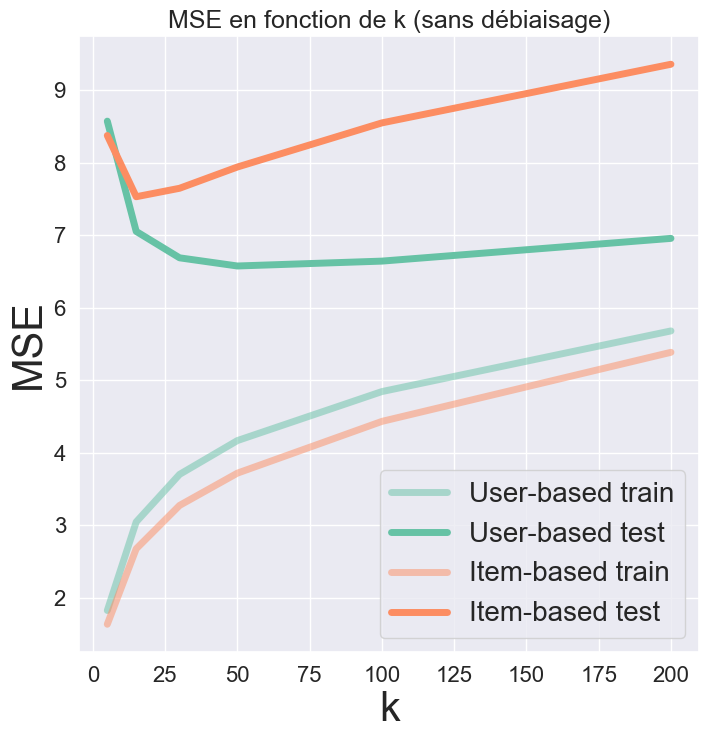

In [31]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

pal = sns.color_palette('Set2', 2)

plt.figure(figsize=(8, 8))
plt.plot(k_array, user_train_mse, c=pal[0], label='User-based train', alpha=0.5, linewidth=5)
plt.plot(k_array, user_test_mse, c=pal[0], label='User-based test', linewidth=5)
plt.plot(k_array, item_train_mse, c=pal[1], label='Item-based train', alpha=0.5, linewidth=5)
plt.plot(k_array, item_test_mse, c=pal[1], label='Item-based test', linewidth=5)
plt.legend(loc='best', fontsize=20)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.xlabel('k', fontsize=30)
plt.ylabel('MSE', fontsize=30)
plt.title('MSE en fonction de k (sans débiaisage)', fontsize=18);

**Question : Que concluez-vous ?**

La MSE sur le train augmente avec $k$ (plus on ajoute de voisins, moins le modèle "surapprend" les préférences très locales), tandis que la MSE sur le test diminue puis se stabilise (ou remonte légèrement) : il y a un compromis biais-variance classique. Un $k$ trop petit sur-ajuste à quelques voisins bruités ; un $k$ trop grand se rapproche de la moyenne pondérée par tous, qu'on a vu être mauvaise. L'approche item-based tend à être plus stable et légèrement meilleure que l'approche user-based sur ce jeu de données, ce qui est cohérent avec la littérature (les items ont souvent des profils de notation plus stables que les utilisateurs).

### Biais des utilisateurs

Nous pouvons proposer une version débiaisée des notes des utilisateurs. En effet, certains utilisateurs ont une tendance à ne mettre que des bonnes (ou des mauvaises) évaluations. On peut supposer cependant que les différences, pour chaque utilisateur, sont significatives. Si quelqu'un "note bas", ses notes seront (par exemple) entre 1 et 3. On suppose qu'il préfère les films notés 3 aux films notés 1. En revanche, ses 3 ne seront pas comparables à ceux de quelqu'un qui "note haut" (pour lequel les notes seraient entre 3 et 5, 3 étant alors une "mauvaise note").

Pour débiaiser, nous allons retirer des notes de chaque utilisateur la moyenne de ses notes (avant prédiction). On rajoutera cette moyenne à la fin, pour obtenir une prédiction :

$$\hat{r}_{ui} = \bar{r}_u + \frac{\sum_{u'} \text{sim}(u, u') (r_{u'i} - \bar{r}_{u'})}{\sum_{u'} |\text{sim}(u, u')|}$$

où $\bar{r}_u$ est la moyenne des notes de $u$.

In [32]:
def predict_nobias(ratings, similarity, kind='user'):
    if kind == 'user':
        user_bias = ratings.mean(axis=1)
        ratings = (ratings - user_bias[:, np.newaxis]).copy()
        pred = similarity.dot(ratings) / np.array([np.abs(similarity).sum(axis=1)]).T
        pred += user_bias[:, np.newaxis]
    elif kind == 'item':
        item_bias = ratings.mean(axis=0)
        ratings = (ratings - item_bias[np.newaxis, :]).copy()
        pred = ratings.dot(similarity) / np.array([np.abs(similarity).sum(axis=1)])
        pred += item_bias[np.newaxis, :]

    return pred

In [33]:
user_pred = predict_nobias(train, user_similarity, kind='user')
print('Bias-subtracted User-based CF MSE: ' + str(get_mse(user_pred, test)))

item_pred = predict_nobias(train, item_similarity, kind='item')
print('Bias-subtracted Item-based CF MSE: ' + str(get_mse(item_pred, test)))

Bias-subtracted User-based CF MSE: 8.789213841363829
Bias-subtracted Item-based CF MSE: 9.798860254438546


**Question : Que pensez-vous de ces chiffres ?**

Les résultats sont en réalité mitigés : pour l'approche item-based, le débiaisage améliore nettement la MSE (11.60 → 9.80), ce qui est cohérent avec l'idée qu'on retire le biais moyen de chaque film avant de pondérer par la similarité. En revanche, pour l'approche user-based, la MSE se dégrade légèrement (8.51 → 8.79) : le simple retrait de la moyenne par utilisateur ne suffit pas à compenser le fait que la pondération porte toujours sur *tous* les utilisateurs, y compris les moins pertinents, ce qui reste le problème dominant identifié dans la section précédente. Le débiaisage seul n'est donc pas systématiquement bénéfique ; c'est surtout sa combinaison avec la restriction top-$k$ (section suivante) qui doit permettre de cumuler les deux bénéfices.

### Combiner prédictions débiaisées et top-$k$

Enfin, nous pouvons proposer une version combinée (débiaisée et top-$k$) de notre recommandation simple.

In [34]:
def predict_topk_nobias(ratings, similarity, kind='user', k=40):
    pred = np.zeros(ratings.shape)
    if kind == 'user':
        user_bias = ratings.mean(axis=1)
        ratings = (ratings - user_bias[:, np.newaxis]).copy()
        for i in range(ratings.shape[0]):
            top_k_users = np.argsort(similarity[:, i])[:-k - 1:-1]
            for j in range(ratings.shape[1]):
                pred[i, j] = similarity[i, :][top_k_users].dot(ratings[:, j][top_k_users])
                pred[i, j] /= np.sum(np.abs(similarity[i, :][top_k_users]))
        pred += user_bias[:, np.newaxis]
    if kind == 'item':
        item_bias = ratings.mean(axis=0)
        ratings = (ratings - item_bias[np.newaxis, :]).copy()
        for j in range(ratings.shape[1]):
            top_k_items = np.argsort(similarity[:, j])[:-k - 1:-1]
            for i in range(ratings.shape[0]):
                pred[i, j] = similarity[j, :][top_k_items].dot(ratings[i, :][top_k_items].T)
                pred[i, j] /= np.sum(np.abs(similarity[j, :][top_k_items]))
        pred += item_bias[np.newaxis, :]

    return pred

In [35]:
k_array = [5, 15, 30, 50, 100, 200]
user_train_mse = []
user_test_mse = []
item_test_mse = []
item_train_mse = []

for k in k_array:
    user_pred = predict_topk_nobias(train, user_similarity, kind='user', k=k)
    item_pred = predict_topk_nobias(train, item_similarity, kind='item', k=k)

    user_train_mse += [get_mse(user_pred, train)]
    user_test_mse += [get_mse(user_pred, test)]

    item_train_mse += [get_mse(item_pred, train)]
    item_test_mse += [get_mse(item_pred, test)]

    print(f"k={k:>3}  user_test_mse={user_test_mse[-1]:.4f}  item_test_mse={item_test_mse[-1]:.4f}")

k=  5  user_test_mse=8.9186  item_test_mse=9.0889


k= 15  user_test_mse=7.5014  item_test_mse=8.2865


k= 30  user_test_mse=7.1706  item_test_mse=8.3416


k= 50  user_test_mse=7.0774  item_test_mse=8.5458


k=100  user_test_mse=7.1634  item_test_mse=8.9204


k=200  user_test_mse=7.4759  item_test_mse=9.2907


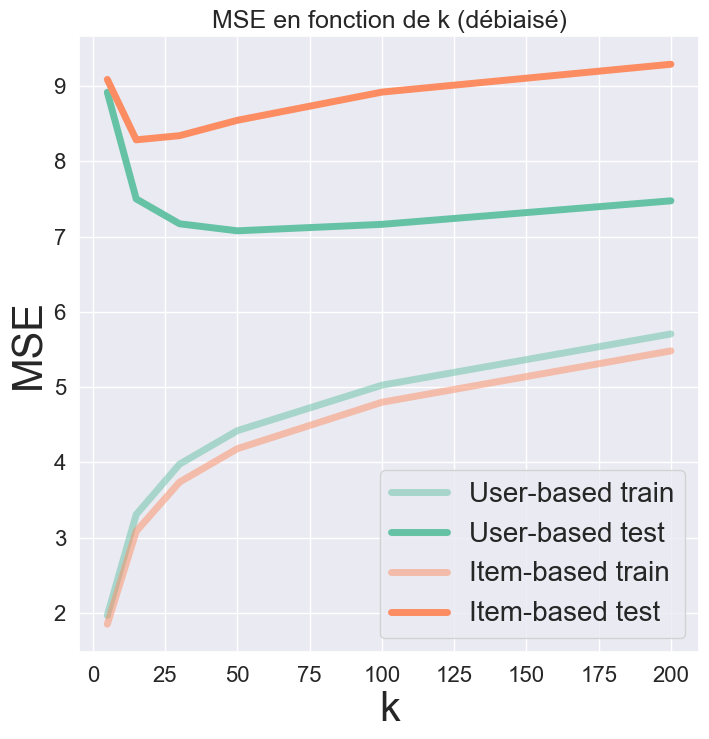

In [36]:
pal = sns.color_palette('Set2', 2)

plt.figure(figsize=(8, 8))
plt.plot(k_array, user_train_mse, c=pal[0], label='User-based train', alpha=0.5, linewidth=5)
plt.plot(k_array, user_test_mse, c=pal[0], label='User-based test', linewidth=5)
plt.plot(k_array, item_train_mse, c=pal[1], label='Item-based train', alpha=0.5, linewidth=5)
plt.plot(k_array, item_test_mse, c=pal[1], label='Item-based test', linewidth=5)
plt.legend(loc='best', fontsize=20)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.xlabel('k', fontsize=30)
plt.ylabel('MSE', fontsize=30)
plt.title('MSE en fonction de k (débiaisé)', fontsize=18);

**Question : Que concluez-vous ?**

Contrairement à l'intuition, la combinaison débiaisage + top-$k$ n'améliore pas la MSE de test par rapport au top-$k$ seul sur ce jeu de données : au meilleur $k$, le top-$k$ simple atteint environ 6.57 (user-based, $k$≈50) et 7.53 (item-based, $k$≈15), contre environ 7.08 et 8.29 pour la version débiaisée. Cela rejoint l'observation de la section précédente : ici, le retrait de la moyenne par utilisateur/item n'apporte pas de gain net une fois qu'on a déjà restreint le voisinage aux $k$ plus proches — le top-$k$ à lui seul corrige déjà l'essentiel du problème (le bruit apporté par les voisins non pertinents), et le débiaisage, qui recentre chaque profil sur sa propre moyenne, peut au passage réduire l'amplitude du signal utile porté par les voisins les plus proches. Les deux techniques ne sont donc pas simplement additives sur ces données : leurs effets se chevauchent partiellement, et il faudrait un jeu de données avec des biais utilisateurs plus marqués pour que la combinaison surpasse clairement le top-$k$ seul.

### Corrélations entre items ?

Comme nous travaillons avec des films, nous pouvons essayer de regarder si des corrélations simples entre les colonnes de la matrice nous paraissent "sensées". Regardons les données des films.

In [37]:
!head -2 u.item

1|Toy Story (1995)|01-Jan-1995||http://us.imdb.com/M/title-exact?Toy%20Story%20(1995)|0|0|0|1|1|1|0|0|0|0|0|0|0|0|0|0|0|0|0
2|GoldenEye (1995)|01-Jan-1995||http://us.imdb.com/M/title-exact?GoldenEye%20(1995)|0|1|1|0|0|0|0|0|0|0|0|0|0|0|0|0|1|0|0


Avec les fonctions de similarités construites plus haut, on peut écrire une fonction retournant les films les plus similaires pour un film donné. Le film entré est le premier de la liste (il est le plus similaire à lui-même).

In [38]:
idx_to_movie = {}
with open('u.item', 'r', encoding='utf8', errors='ignore') as f:
    for line in f.readlines():
        info = line.split('|')
        idx_to_movie[int(info[0]) - 1] = info[1]

def top_k_movies(similarity, mapper, movie_idx, k=6):
    return [mapper[x] for x in np.argsort(similarity[movie_idx, :])[:-k - 1:-1]]

In [39]:
idx = 0  # Toy Story
# on utilise ici la fonction item_similarity définie bien plus tôt (retournez la voir, si nécessaire)
movies = top_k_movies(item_similarity, idx_to_movie, idx)
for movie in enumerate(movies):
    print(movie)

(0, 'Toy Story (1995)')
(1, 'Independence Day (ID4) (1996)')
(2, 'Star Wars (1977)')
(3, 'Return of the Jedi (1983)')
(4, 'Star Trek: First Contact (1996)')
(5, 'Rock, The (1996)')


In [40]:
idx = 1  # GoldenEye
movies = top_k_movies(item_similarity, idx_to_movie, idx)
for movie in enumerate(movies):
    print(movie)

(0, 'GoldenEye (1995)')
(1, 'Under Siege (1992)')
(2, 'True Lies (1994)')
(3, 'Batman (1989)')
(4, 'Top Gun (1986)')
(5, 'Die Hard 2 (1990)')


In [41]:
idx = 20  # Muppet Treasure Island
movies = top_k_movies(item_similarity, idx_to_movie, idx)
for movie in enumerate(movies):
    print(movie)

(0, 'Muppet Treasure Island (1996)')
(1, 'Stargate (1994)')
(2, 'Empire Strikes Back, The (1980)')
(3, 'Addams Family Values (1993)')
(4, 'Sgt. Bilko (1996)')
(5, 'Monty Python and the Holy Grail (1974)')


**Question : Que pensez-vous de ces listes ?**

Les films retournés partagent souvent le genre ou le ton du film de référence (par exemple, des films d'action/aventure similaires à *GoldenEye*, ou des films familiaux proches de *Toy Story*), ce qui montre que la similarité cosinus sur les colonnes de la matrice capte un vrai signal de goût commun des utilisateurs. Cela dit, les résultats sont aussi influencés par la popularité : des films très notés ont des vecteurs de notes plus "denses", ce qui peut gonfler artificiellement leur similarité avec d'autres films populaires, même sans lien thématique fort.

### Pearson, une autre mesure de similarité

La similarité cosinus est sensible à l'échelle absolue des notes. La corrélation de Pearson, elle, mesure la corrélation *linéaire* entre les vecteurs de notes après centrage, ce qui la rend moins sensible aux biais globaux de notation.

In [42]:
from sklearn.metrics import pairwise_distances
item_correlation = 1 - pairwise_distances(train.T, metric='correlation')
item_correlation[np.isnan(item_correlation)] = 0.

Regardons les mêmes listes.

In [43]:
idx = 0  # Toy Story
movies = top_k_movies(item_correlation, idx_to_movie, idx)
for movie in enumerate(movies):
    print(movie)

(0, 'Toy Story (1995)')
(1, 'Independence Day (ID4) (1996)')
(2, 'Aladdin (1992)')
(3, 'Willy Wonka and the Chocolate Factory (1971)')
(4, 'Return of the Jedi (1983)')
(5, 'Twister (1996)')


In [44]:
idx = 1  # GoldenEye
movies = top_k_movies(item_correlation, idx_to_movie, idx)
for movie in enumerate(movies):
    print(movie)

(0, 'GoldenEye (1995)')
(1, 'Under Siege (1992)')
(2, 'Cliffhanger (1993)')
(3, 'True Lies (1994)')
(4, 'Batman (1989)')
(5, 'Top Gun (1986)')


In [45]:
idx = 20  # Muppet Treasure Island
movies = top_k_movies(item_correlation, idx_to_movie, idx)
for movie in enumerate(movies):
    print(movie)

(0, 'Muppet Treasure Island (1996)')
(1, 'Sgt. Bilko (1996)')
(2, 'Naked Gun 33 1/3: The Final Insult (1994)')
(3, 'Addams Family Values (1993)')
(4, 'Stargate (1994)')
(5, 'Hot Shots! Part Deux (1993)')


**Question : Que concluez-vous ?**

Les recommandations obtenues avec la corrélation de Pearson diffèrent sensiblement de celles obtenues avec la similarité cosinus : Pearson tend à mettre en avant des films de niche partageant un profil de notation similaire (mêmes utilisateurs les aiment/détestent de façon corrélée), même s'ils sont peu notés, alors que le cosinus favorise des films populaires ayant globalement de bonnes notes. Aucune des deux mesures n'est universellement meilleure : Pearson corrige le biais de notation moyen mais est plus instable sur peu d'observations communes (paires d'items peu co-notées), tandis que le cosinus est plus robuste mais plus sensible à la popularité globale.